# E18 · Areal models on a graph: ICAR, proper CAR and BYM2

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Male lip cancer in the 56 districts of Scotland, 1975-80 (Clayton & Kaldor 1987): observed and expected cases, % of workers in agriculture, fishing and forestry, and the district **polygons** (GeoDa Center); the hand-edited WinBUGS neighbour list for comparison |
| **You will learn** | Building a contiguity graph (queen / rook) from polygons in plain NumPy · degree, connected components and **islands** · the graph Laplacian and what it implies for marginal variances · `pm.ICAR` and its sum-to-zero constraint · proper `pm.CAR` and why its $\alpha$ piles up near 1 · BYM2: scaling the ICAR with the generalised inverse of the Laplacian, the mixing parameter $\rho$ · three failures and their fixes · smoothed relative-risk and **exceedance-probability** maps · a residual Moran's I check · LOO and leave-districts-out cross-validation · **spatial confounding** of a covariate effect · adjacency vs distance (E07) |

Disease counts are rarely published per person or per coordinate. They are published per
**area**: a district, a county, a postcode. Two neighbouring districts share a population
that commutes, a coastline, an industry, a water supply, so their disease rates tend to be
alike - but "neighbouring" is a statement about a **map**, not about a distance. Skye and
the Western Isles are neighbours across a strait; Glasgow and one of its suburbs are
neighbours across a street. The natural object is a **graph**: one node per area, an edge
for "shares a border".

This notebook builds that graph from real polygons and puts the three classic graph priors
on it: the **intrinsic CAR** (ICAR), the **proper CAR**, and **BYM2**, the modern default
for disease mapping. It deliberately runs into the three problems that trip people up in
practice - islands, a CAR parameter that will not leave the boundary, and a variance that
means something different on every map - and fixes each one.

**Why this dataset.** The repository already has county polygons for the whole US (E16),
and Minnesota radon (E02) sits on them. But radon is a set of *home measurements*, not
areal counts, and fitting it with a county-level CAR would teach the wrong lesson. The
Scottish lip-cancer data is the benchmark for areal models precisely because it is what
these models are for: small **counts** with a known **expected** count per area, very
unequal populations (from 1.4 to 88 expected cases), a covariate with a plausible
mechanism (sunlight: outdoor work), real islands, and results that have been reproduced in
WinBUGS, INLA, CARBayes and Stan, so we can check ours.

In [1]:
import json
import logging
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from matplotlib.collections import LineCollection, PolyCollection
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
from scipy.sparse.csgraph import connected_components
from scipy.special import logsumexp

from pymc_challenges import data

RANDOM_SEED = 1987
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # ~40 fits below: no banner per fit
BLUE, ORANGE, AQUA, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c8374b"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Question and data

Between 1975 and 1980, 536 men in Scotland were diagnosed with lip cancer. For each of the
56 districts we know the observed count $y_i$ and an **expected** count $E_i$: what the
district would have seen if every age group had the national rate. Their ratio is the
**standardised morbidity ratio** $\text{SMR}_i = y_i / E_i$, the raw estimate of the
district's relative risk. The epidemiological question is twofold:

1. **Where** is the risk genuinely elevated, once the noise of small counts is accounted for?
2. **Does outdoor work explain it?** Lip cancer is linked to sunlight exposure, and `AFF`
   is the percentage of the workforce in agriculture, fishing and forestry.

The data come as a GeoJSON of district polygons with the counts as properties.

In [2]:
data.describe("scotland_lip_geojson")
geo = json.load(open(data.path("scotland_lip_geojson")))
lip = pd.DataFrame([f["properties"] for f in geo["features"]])
rings = [np.asarray(f["geometry"]["coordinates"][0]) for f in geo["features"]]  # outer rings
print({f["geometry"]["type"] for f in geo["features"]}, "- coordinates in metres (British National Grid)")
lip = lip.rename(columns={"NAME": "district", "CANCER": "y", "CEXP": "E"})
lip["SMR"] = lip.y / lip.E
N = len(lip)
names = lip.district.to_numpy(dtype=object)
y, E = lip.y.to_numpy(), lip.E.to_numpy()
aff = lip.AFF.to_numpy(float)
lip[["district", "y", "E", "SMR", "AFF", "POP"]].sort_values("SMR").iloc[[0, 1, 2, 27, 28, -3, -2, -1]].round(2)

scotland_lip_geojson: 56 Scottish districts (British National Grid polygons, metres) with observed cases CANCER, expected cases CEXP, population POP and % in agriculture/fishing/forestry AFF. GeoJSON: use data.path().
  source: Clayton & Kaldor (1987) male lip cancer 1975-80 via Cressie (1993); expected counts and AFF from Lawson et al. (1999); WinBUGS boundaries prepared by Luc Anselin for the GeoDa Center data-and-lab.
  url:    https://geodacenter.github.io/data-and-lab/data/scotlip.zip
{'Polygon'} - coordinates in metres (British National Grid)


,district,y,E,SMR,AFF,POP
55,Annandale,0,1.76,0.00,10,103412
54,Tweeddale,0,4.16,0.00,16,38704
53,Strathkelvin,1,7.03,0.14,1,246744
28,Perth-Kinross,16,14.37,1.11,10,346041
27,EastLothian,10,8.96,1.12,7,231185
2,Caithness,11,3.04,3.62,10,83190
1,Banff-Buchan,39,8.66,4.50,16,231337
0,Skye-Lochalsh,9,1.38,6.52,16,28324


Every geometry is a single polygon (GeoDa merged multi-part islands into one ring), with
coordinates on the British National Grid - metres on a flat projection, so an aspect ratio
of 1 draws Scotland without distortion. A choropleth needs no GIS library: a
`PolyCollection` of the rings coloured by value (as in E16).

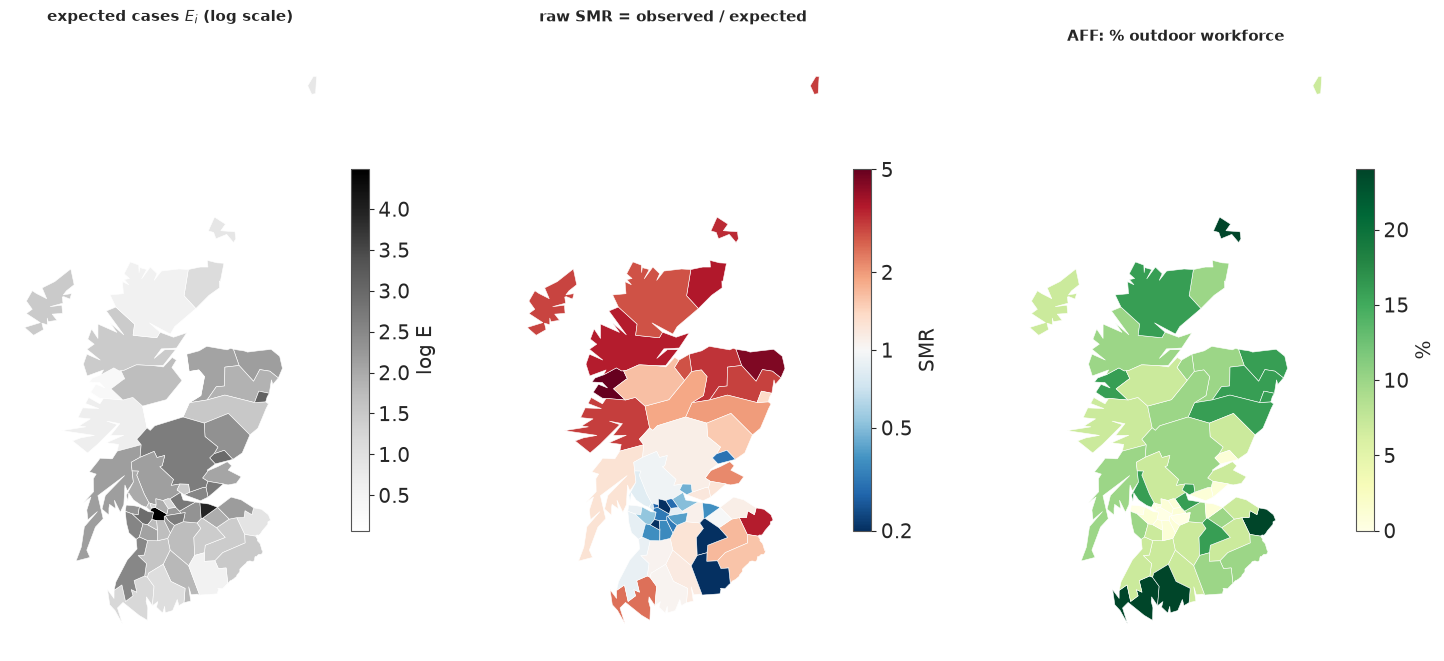

In [3]:
def draw_map(ax, values, cmap="viridis", norm=None, title="", cbar_label="", edges=None, **kw):
    pc = PolyCollection(rings, array=np.asarray(values, float), cmap=cmap, norm=norm,
                        edgecolor="white", linewidth=0.4, **kw)
    ax.add_collection(pc)
    if edges is not None:
        ax.add_collection(edges)
    ax.autoscale_view()
    ax.set_aspect(1)
    ax.set_axis_off()
    ax.set_title(title, fontsize=11)
    plt.colorbar(pc, ax=ax, shrink=0.6, label=cbar_label)
    return pc


RR_NORM = TwoSlopeNorm(vcenter=0.0, vmin=np.log(0.2), vmax=np.log(5))  # log relative risk, centred at RR = 1


def rr_colorbar_ticks(pc):
    ticks = [0.2, 0.5, 1, 2, 5]
    pc.colorbar.set_ticks(np.log(ticks))
    pc.colorbar.set_ticklabels([str(t) for t in ticks])


fig, axes = plt.subplots(1, 3, figsize=(15, 6.5))
draw_map(axes[0], np.log(E), cmap="Greys", title="expected cases $E_i$ (log scale)", cbar_label="log E")
pc = draw_map(axes[1], np.log(np.clip(lip.SMR, 0.2, None)), cmap="RdBu_r", norm=RR_NORM,
              title="raw SMR = observed / expected", cbar_label="SMR")
rr_colorbar_ticks(pc)
draw_map(axes[2], aff, cmap="YlGn", title="AFF: % outdoor workforce", cbar_label="%");

The raw SMR map shows the pattern that made this dataset famous: high ratios in the north
and west (the Highlands, Skye, the islands), ratios below 1 in the urban central belt.
The outdoor-work map has a similar shape. Two warnings, though. First, the most extreme
SMRs belong to the smallest districts (Skye-Lochalsh: 9 cases where 1.4 were expected),
and the two districts with *zero* cases expected fewer than 5 - their SMR of 0 is mostly
noise. Second, **AFF and the risk share their spatial pattern**, so any model that lets
the risk vary smoothly in space will compete with AFF to explain the same map. Both
themes run through the rest of the notebook.

## 2 · From polygons to a graph

Two districts are **queen** neighbours if their boundaries share at least one point, and
**rook** neighbours if they share at least one boundary *segment* (the names come from
chess: a rook cannot move diagonally across a corner). Topological shapefiles like this
one store a shared border with identical vertices on both sides, so a set intersection of
vertex keys does the job; rounding the coordinates to a tolerance first makes the same
code work on files whose borders were digitised twice.

In [4]:
def contiguity(rings, tol=1.0, rule="queen"):
    """Adjacency matrix from polygon rings: shared vertices (queen) or shared edges (rook)."""
    keys = [[tuple(k) for k in np.round(r / tol).astype(np.int64)] for r in rings]
    if rule == "queen":
        sets = [set(k[:-1]) for k in keys]
    else:
        sets = [{frozenset(e) for e in zip(k[:-1], k[1:]) if e[0] != e[1]} for k in keys]
    n = len(rings)
    W = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i + 1, n):
            W[i, j] = W[j, i] = len(sets[i] & sets[j]) > 0
    return W


W_queen = contiguity(rings, rule="queen")
W_rook = contiguity(rings, rule="rook")
for tol in [1.0, 100.0, 1000.0]:
    print(f"tolerance {tol:6.0f} m: queen edges {contiguity(rings, tol).sum() // 2}")
print(f"queen edges {W_queen.sum() // 2}, rook edges {W_rook.sum() // 2}; corner-only neighbours:",
      [f"{names[i]}-{names[j]}" for i, j in zip(*np.nonzero(np.triu(W_queen - W_rook)))])

tolerance      1 m: queen edges 117
tolerance    100 m: queen edges 117
tolerance   1000 m: queen edges 117
queen edges 117, rook edges 115; corner-only neighbours: ['EastLothian-Edinburgh', 'Falkirk-Clackmannan']


The graph does not depend on the tolerance, and queen and rook differ by two corner
contacts only. We use queen contiguity. Now the graph's anatomy: how many neighbours each
district has, and whether every district can be reached from every other.

4 connected components; component sizes [53, 1, 1, 1]
districts with no neighbour: ['Okney', 'Shetland', 'WesternIsles']


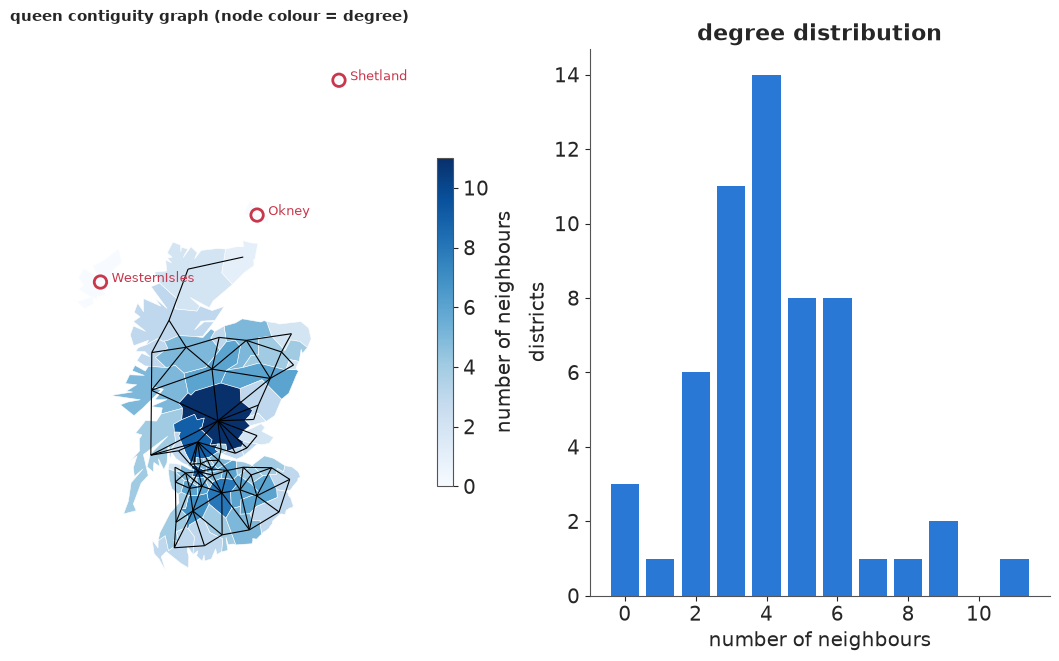

In [5]:
degree = W_queen.sum(1)
n_comp, comp = connected_components(W_queen, directed=False)
islands = np.nonzero(degree == 0)[0]
print(f"{n_comp} connected components; component sizes {np.bincount(comp).tolist()}")
print("districts with no neighbour:", names[islands].tolist())
centroids = np.array([r[:-1].mean(0) for r in rings])


def edge_lines(W, **kw):
    i, j = np.nonzero(np.triu(W))
    return LineCollection(np.stack([centroids[i], centroids[j]], axis=1), **kw)


fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})
draw_map(axes[0], degree, cmap="Blues", title="queen contiguity graph (node colour = degree)",
         cbar_label="number of neighbours", edges=edge_lines(W_queen, color="k", lw=0.8))
axes[0].scatter(*centroids[islands].T, s=80, facecolor="none", edgecolor=RED, lw=2, zorder=5)
for i in islands:
    axes[0].annotate(names[i], centroids[i], xytext=(8, 0), textcoords="offset points", color=RED, fontsize=9)
axes[1].bar(*np.unique(degree, return_counts=True), color=BLUE)
axes[1].set(xlabel="number of neighbours", ylabel="districts", title="degree distribution");

The mainland is one connected piece, but **Orkney, Shetland and the Western Isles touch
nothing**: the graph has four components. (The GeoJSON spells Orkney "Okney"; we keep the
source's spelling.) Degrees range from 0 to 11, and as we will see the degree matters:
under an ICAR prior a district's variance depends on how many neighbours it has.

### A published neighbour list, and why we do not simply trust it

The WinBUGS/GeoBUGS version of this dataset (reproduced in pymc-examples) ships a
hand-edited neighbour list. Comparing it with our polygon graph is instructive.

In [6]:
data.describe("scotland_lip_adjacency")
bugs = data.load("scotland_lip_adjacency")
assert (bugs.CODENO.to_numpy() == lip.CODENO.to_numpy()).all()  # same districts, same order
W_bugs = np.zeros((N, N), dtype=int)
for i, nbrs in enumerate(bugs.ADJ):
    W_bugs[i, np.asarray(json.loads(nbrs)) - 1] = 1
print(f"published list: symmetric {bool((W_bugs == W_bugs.T).all())}, {W_bugs.sum() // 2} edges, "
      f"{connected_components(W_bugs, directed=False)[0]} component")
diff = W_bugs - W_queen
pd.DataFrame(
    [(names[i], names[j], "published only" if diff[i, j] > 0 else "polygons only",
      f"{np.linalg.norm(centroids[i] - centroids[j]) / 1000:.0f}") for i, j in zip(*np.nonzero(np.triu(diff)))],
    columns=["district", "district", "edge in", "centroid distance (km)"])

scotland_lip_adjacency: 56 districts: CANCER, CEXP, AFF and the published (hand-edited, islands linked) neighbour lists ADJ.
  source: Scottish lip cancer data with the WinBUGS GeoBUGS adjacency lists, via pymc-examples.
  url:    https://raw.githubusercontent.com/pymc-devs/pymc-examples/main/examples/data/scotland_lips_cancer.csv
published list: symmetric True, 132 edges, 1 component


,district,district,edge in,centroid distance (km)
0,Skye-Lochalsh,WesternIsles,published only,118
1,Caithness,Okney,published only,60
2,Ross-Cromarty,WesternIsles,published only,106
3,Ross-Cromarty,Nairn,published only,72
4,Okney,Shetland,published only,213
5,Lochaber,WesternIsles,published only,162
6,WesternIsles,Sutherland,published only,120
7,NEFife,Dundee,published only,22
8,Roxburgh,Tweeddale,published only,61
9,Roxburgh,Annandale,polygons only,47


The published list has 132 edges to our 117. The differences fall into four groups:

* **Islands linked by hand**: Orkney to Caithness and Shetland, the Western Isles to four
  mainland districts. This is a modelling decision (ferries, shared fishing grounds), not
  geography.
* **Estuary crossings**: NE Fife - Dundee over the Tay, Dunfermline - Falkirk over the
  Forth, Argyll & Bute to Inverclyde and Cunninghame over the Clyde, plus three more pairs
  facing each other across the Clyde. Again defensible, again a decision.
* **Near misses**: Ross-Cromarty - Nairn (across the Moray Firth) and Stewartry -
  Kyle-Carrick, whose polygons do not touch on this simplified map.
* **Tweeddale and Annandale look swapped.** The polygons say Edinburgh, Midlothian and
  West Lothian border Tweeddale (correct: Peebles is 30 km south of Edinburgh), and that
  Roxburgh and Nithsdale border Annandale (correct: both lie along the Dumfriesshire
  border). The published list says the opposite for all five pairs. Somewhere between
  WinBUGS and this CSV the neighbour lists of the last two districts were attached to the
  wrong rows. It changes little here, since both districts have zero cases, but it is the
  kind of error that only a map reveals.

We build our own graph from the polygons and make the island decision explicitly.

### Is there spatial structure at all? Moran's I

Before modelling, a classic descriptive check. **Moran's I** is the correlation between a
value and the average of its neighbours,
$I = \frac{N}{\sum_{ij} W_{ij}} \frac{\sum_{ij} W_{ij} z_i z_j}{\sum_i z_i^2}$ with
$z$ centred; its reference distribution comes from shuffling the values over the map. We
apply it to the log SMR (with 0.5 added to the counts so zeros are finite) on the mainland
graph.

In [7]:
def morans_i(z, W):
    z = z - z.mean()
    return len(z) / W.sum() * (z @ W @ z) / (z @ z)


def moran_test(z, W, n_perm=4999):
    obs = morans_i(z, W)
    perm = np.array([morans_i(rng.permutation(z), W) for _ in range(n_perm)])
    return obs, (1 + (perm >= obs).sum()) / (n_perm + 1)


log_smr = np.log((y + 0.5) / E)
I_obs, p_val = moran_test(log_smr, W_queen)
print(f"Moran's I of log SMR = {I_obs:.2f} (permutation p = {p_val:.4f}; expectation under no pattern "
      f"{-1 / (N - 1):.2f})")
I_aff, p_aff = moran_test(aff, W_queen)
print(f"Moran's I of AFF      = {I_aff:.2f} (permutation p = {p_aff:.4f})")

Moran's I of log SMR = 0.50 (permutation p = 0.0002; expectation under no pattern -0.02)


Moran's I of AFF      = 0.29 (permutation p = 0.0018)


Strong positive autocorrelation in both - neighbouring districts have similar SMRs and
similar outdoor workforces. Moran's I tells us *that* there is structure. The models below
tell us *how much*, *where*, and *how much of it the covariate explains*.

## 3 · Graph priors: ICAR, proper CAR and BYM2

All models share the Poisson likelihood with the expected count as offset,

$$y_i \sim \text{Poisson}(E_i \, r_i), \qquad \log r_i = \beta_0 + \beta_1 x_i + u_i,$$

with $x_i$ = (AFF$_i$ - mean) / 10, so $e^{\beta_1}$ is the relative risk per 10
percentage points of outdoor workforce. They differ only in the prior for the district
effects $u$.

**Graph Laplacian.** With $D$ the diagonal matrix of degrees, $Q = D - W$ is the graph
Laplacian, and $u^\top Q u = \sum_{i \sim j} (u_i - u_j)^2$ sums the squared differences
over the edges. Every graph prior here penalises that sum.

* **ICAR** (intrinsic CAR, Besag 1974): $p(u) \propto \exp(-\frac{1}{2\sigma^2} u^\top Q u)$.
  Equivalently, each $u_i$ given the rest is Normal around **the mean of its
  neighbours** with variance $\sigma^2 / d_i$. $Q$ is singular - adding a constant to every
  $u_i$ does not change a single difference - so the density is improper and must be pinned
  down with a **sum-to-zero constraint**. `pm.ICAR` imposes it softly, as a tight Normal on
  $\sum_i u_i$. One constant per *connected component* is free, which is why islands matter.
* **Proper CAR**: precision $\tau (D - \alpha W)$ with $0 < \alpha < 1$. Proper for
  $\alpha < 1$, and $\alpha \to 1$ recovers the ICAR.
* **BYM** (Besag, York & Mollié 1991): $u = \sigma_\phi \phi + \sigma_\theta \theta$, an ICAR
  component plus an iid one, because real maps have both smooth and area-specific variation.
* **BYM2** (Riebler et al. 2016): $u = \sigma\left(\sqrt{\rho/s}\,\phi + \sqrt{1-\rho}\,\theta\right)$,
  the same sum re-parameterised by a total scale $\sigma$ and a **mixing proportion**
  $\rho \in (0, 1)$. The constant $s$ is the **scaling factor** of the graph, defined next.

### Why the ICAR needs scaling: variances come from the graph

Under the constrained ICAR with $\sigma = 1$, the covariance of $\phi$ is the
**generalised inverse** $Q^{+}$ of the Laplacian. Its diagonal - the marginal variances -
is not constant: it depends on each area's position in the graph. The scaling factor is
their geometric mean, $s = \exp\left(\frac{1}{N}\sum_i \log Q^{+}_{ii}\right)$; dividing
$\phi$ by $\sqrt{s}$ gives a field whose typical marginal variance is 1, the same as the
iid $\theta$. Only then do $\sigma$ and $\rho$ mean the same thing on every map.

To compute it we need a connected graph. We link each island to the district whose
boundary is closest to it - a rule we can state and defend, where the published list
made a judgement call per island.

In [8]:
def min_boundary_distance(i, j):
    return np.sqrt(((rings[i][:, None, :] - rings[j][None, :, :]) ** 2).sum(-1)).min()


W = W_queen.copy()
for i in islands:
    dist = np.array([np.inf if j == i else min_boundary_distance(i, j) for j in range(N)])
    j = int(dist.argmin())
    W[i, j] = W[j, i] = 1
    print(f"link {names[i]:>13s} -> {names[j]:<14s} ({dist[j] / 1000:.0f} km of sea)")
print(f"linked graph: {W.sum() // 2} edges, {connected_components(W, directed=False)[0]} component")


def scaling_factor(W):
    Q = np.diag(W.sum(1)) - W
    return np.exp(np.mean(np.log(np.diag(np.linalg.pinv(Q)))))


Q = np.diag(W.sum(1)) - W
Q_plus = np.linalg.pinv(Q)  # the generalised inverse = covariance of the constrained ICAR
s = scaling_factor(W)
print(f"scaling factor s = {s:.3f}; marginal variances range {np.diag(Q_plus).min():.2f} - {np.diag(Q_plus).max():.2f}")

link         Okney -> Caithness      (28 km of sea)
link      Shetland -> Okney          (192 km of sea)
link  WesternIsles -> Ross-Cromarty  (41 km of sea)
linked graph: 120 edges, 1 component
scaling factor s = 0.632; marginal variances range 0.23 - 4.60


Shetland's nearest district is Orkney, so the two northern islands form a chain hanging off
Caithness; the graph is now connected. (The 192 km is an artefact: Shetland is drawn as a
crude 7-point outline of its northern part only. The rule still picks Orkney.) The marginal
variances of a unit ICAR on the linked graph span a factor of twenty. Where does that come from? The next figure plots them against the
degree, and also asks the question that separates this notebook from E07: **how does prior
correlation relate to distance?**

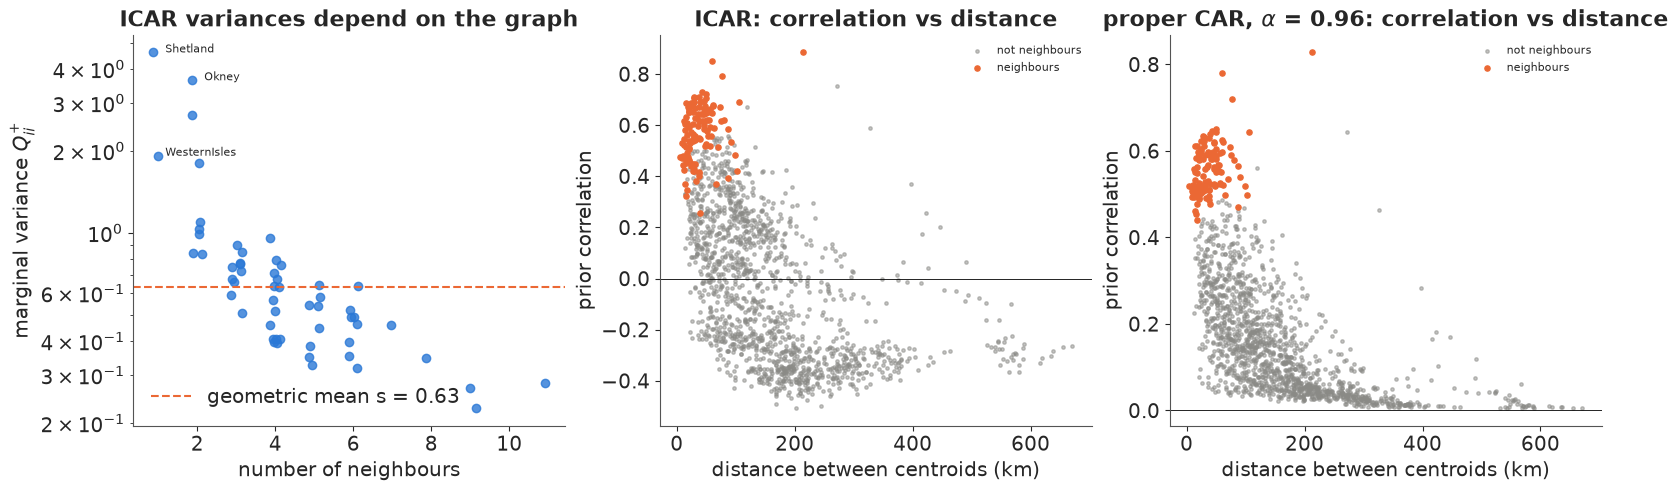

In [9]:
var_icar = np.diag(Q_plus)
corr_icar = Q_plus / np.sqrt(np.outer(var_icar, var_icar))
alpha_demo = 0.96
cov_car = np.linalg.inv(np.diag(W.sum(1)) - alpha_demo * W)
corr_car = cov_car / np.sqrt(np.outer(np.diag(cov_car), np.diag(cov_car)))
dist_km = np.linalg.norm(centroids[:, None] - centroids[None], axis=-1) / 1000
iu = np.triu_indices(N, 1)
is_edge = W[iu] == 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].scatter(W.sum(1) + rng.uniform(-0.15, 0.15, N), var_icar, color=BLUE, alpha=0.8)
for i in islands:
    axes[0].annotate(names[i], (W.sum(1)[i], var_icar[i]), xytext=(5, 0), textcoords="offset points", fontsize=8)
axes[0].axhline(s, color=ORANGE, ls="--", label=f"geometric mean s = {s:.2f}")
axes[0].set(xlabel="number of neighbours", ylabel=r"marginal variance $Q^{+}_{ii}$", yscale="log",
            title="ICAR variances depend on the graph")
axes[0].legend()
for ax, corr, label in [(axes[1], corr_icar, "ICAR"), (axes[2], corr_car, rf"proper CAR, $\alpha$ = {alpha_demo}")]:
    ax.scatter(dist_km[iu][~is_edge], corr[iu][~is_edge], s=6, color=GREY, alpha=0.5, label="not neighbours")
    ax.scatter(dist_km[iu][is_edge], corr[iu][is_edge], s=14, color=ORANGE, label="neighbours")
    ax.axhline(0, color="k", lw=0.6)
    ax.set(xlabel="distance between centroids (km)", ylabel="prior correlation", title=f"{label}: correlation vs distance")
    ax.legend(loc="upper right", fontsize=8)

Three things to take from this figure.

* **Poorly connected areas get large prior variances.** A district with a single neighbour
  (the islands, peninsulas) is pinned down by one difference only; a central district with
  eight neighbours is held by eight. Under the ICAR the variance is a property of the
  *graph*, so the same $\sigma$ implies a different spread of risk on a different map - hence
  the scaling factor $s$ in BYM2.
* **Correlation is not a function of distance.** Under the ICAR, pairs 50 km apart have
  prior correlations anywhere from about 0.8 to below zero; two neighbours can be more or less correlated depending on
  what else they touch. A stationary GP (E07) makes correlation a smooth, decreasing function
  of distance by construction. An adjacency prior makes it a function of **topology**: a
  small urban district 5 km across and a Highland district 100 km across are treated alike
  if they have the same neighbours.
* **The ICAR's correlations go negative at long range** - a consequence of the sum-to-zero
  constraint: if the far north is above average, something else must be below. The proper
  CAR (here with $\alpha = 0.96$, near its posterior median below) has no constraint: its
  correlations decay towards zero instead, but scatter just as widely at a given distance.

Which is right? Neither in general. Adjacency is the natural choice when the areas are the
unit at which things happen (health boards, school districts, policies) and when areas
differ wildly in size; distance is natural for a continuous process observed at points
(earthquakes, E07; soil, air quality). For areal data a GP on centroids ignores the areas'
very different sizes, and an ICAR ignores the kilometres. An ICAR is also cheap: its
precision matrix is sparse, with no $N \times N$ covariance to factorise.

### Prior predictive, by hand

`pm.ICAR` has no random number generator (`pm.sample_prior_predictive` raises
`NotImplementedError: Cannot sample from ICAR prior`), so we draw from it ourselves: with
$Q^{+} = V \Lambda V^\top$, a constrained ICAR draw is $V \Lambda^{1/2} z$. Below: four draws
of the scaled ICAR field $\phi/\sqrt{s}$ and four of the iid field $\theta$, both on the scale
of log relative risk with $\sigma = 0.5$.

pm.sample_prior_predictive: Cannot sample from ICAR prior
check: mean marginal variance of the scaled draws (geometric) = 1.00


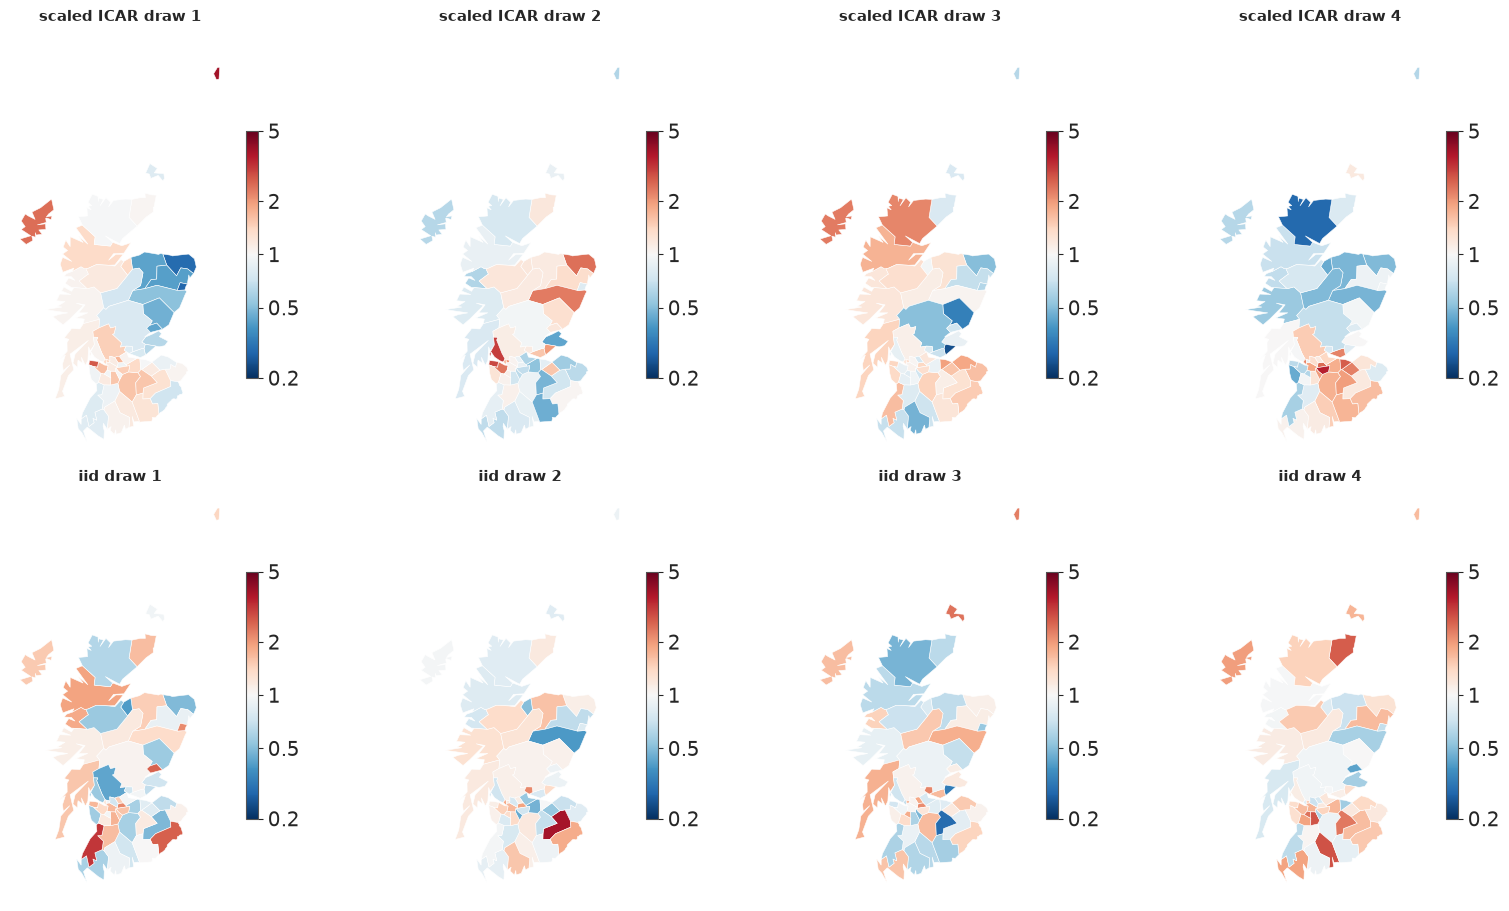

In [10]:
with pm.Model() as m_check, warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)  # a Numba "object mode" notice before the error
    pm.ICAR("phi", W=W)
    try:
        pm.sample_prior_predictive(draws=10, random_seed=RANDOM_SEED)
    except NotImplementedError as err:
        print("pm.sample_prior_predictive:", err)

lam, V = np.linalg.eigh(Q_plus)
lam = np.clip(lam, 0, None)  # the constant direction has eigenvalue 0 (numerically ~1e-16)


def draw_scaled_icar(n):
    return (V * np.sqrt(lam / s)) @ rng.standard_normal((N, n))


phi_draws = draw_scaled_icar(4).T
theta_draws = rng.standard_normal((4, N))
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for k in range(4):
    pc = draw_map(axes[0, k], 0.5 * phi_draws[k], cmap="RdBu_r", norm=RR_NORM, title=f"scaled ICAR draw {k + 1}")
    rr_colorbar_ticks(pc)
    pc = draw_map(axes[1, k], 0.5 * theta_draws[k], cmap="RdBu_r", norm=RR_NORM, title=f"iid draw {k + 1}")
    rr_colorbar_ticks(pc)
print(f"check: mean marginal variance of the scaled draws (geometric) = "
      f"{np.exp(np.mean(np.log(np.var(draw_scaled_icar(20000), axis=1)))):.2f}")

The ICAR draws are smooth patches spanning several districts, most variable at the poorly
connected edges; the iid draws are confetti. Both have the same typical variance, so a
HalfNormal(1) prior on $\sigma$ means the same thing for either. Its median, $\sigma
\approx 0.67$, puts two thirds of the districts within a factor of about 2 of the baseline
risk; its upper tail allows much more. Loose, but not absurd for a rare cancer in small
populations.

## 4 · Fitting the ladder

Five models, each adding one idea: Poisson with the covariate only; iid district effects
(a Poisson-lognormal: extra-Poisson variation, no space); ICAR; proper CAR; BYM2. One
builder function makes them all, so that the only thing that changes is the prior on $u$.
The ICAR and BYM2 components are **non-centred** (`pm.ICAR` with unit scale, multiplied by
$\sigma$), the proper CAR is centred because `pm.CAR` takes the precision directly.
`obs_idx` restricts the likelihood to a subset of districts - we will need it for
cross-validation in section 8.

In [11]:
x = (aff - aff.mean()) / 10
coords = {"district": names}


def build(kind, W=W, obs_idx=None, scale=None):
    obs = np.arange(N) if obs_idx is None else np.asarray(obs_idx)
    with pm.Model(coords=coords) as model:
        b0 = pm.Normal("b0", 0.0, 1.0)
        b1 = pm.Normal("b1", 0.0, 1.0)
        if kind == "poisson":
            u = 0.0
        elif kind == "iid":
            sigma = pm.HalfNormal("sigma", 1.0)
            u = sigma * pm.Normal("theta", 0.0, 1.0, dims="district")
        elif kind == "icar":
            sigma = pm.HalfNormal("sigma", 1.0)
            u = sigma * pm.ICAR("phi", W=W, dims="district")
        elif kind == "car":
            sigma = pm.HalfNormal("sigma", 1.0)
            alpha = pm.Uniform("alpha", 0.0, 1.0)
            u = pm.CAR("phi", mu=np.zeros(N), W=W, alpha=alpha, tau=1 / sigma**2, dims="district")
        elif kind == "bym":  # the original, unscaled BYM
            sigma_phi = pm.HalfNormal("sigma_phi", 1.0)
            sigma_theta = pm.HalfNormal("sigma_theta", 1.0)
            phi = pm.ICAR("phi", W=W, dims="district")
            theta = pm.Normal("theta", 0.0, 1.0, dims="district")
            u = sigma_phi * phi + sigma_theta * theta
        elif kind == "bym2":
            s_ = scaling_factor(W) if scale is None else scale
            sigma = pm.HalfNormal("sigma", 1.0)
            rho = pm.Beta("rho", 1.0, 1.0)
            phi = pm.ICAR("phi", W=W, dims="district")
            theta = pm.Normal("theta", 0.0, 1.0, dims="district")
            u = sigma * (pm.math.sqrt(rho / s_) * phi + pm.math.sqrt(1 - rho) * theta)
        log_rr = pm.Deterministic("log_rr", b0 + b1 * x + u, dims="district")
        if obs_idx is None:
            pm.Poisson("y", mu=E * pm.math.exp(log_rr), observed=y, dims="district")
        else:
            pm.Poisson("y", mu=E[obs] * pm.math.exp(log_rr[obs]), observed=y[obs])
    return model


def fit(model, loglik=True, **kw):
    with model:
        idata = pm.sample(target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False, **kw)
        if loglik:
            pm.compute_log_likelihood(idata, progressbar=False)
    return idata


def diagnostics(idata, var_names):
    summ = az.summary(idata, var_names=var_names, round_to=3)
    return summ.assign(divergences=int(idata.sample_stats["diverging"].sum()))[
        ["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "ess_tail", "r_hat", "divergences"]]


warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto")  # Pareto k: section 8
kinds = ["poisson", "iid", "icar", "car", "bym2"]
fits, loos = {}, {}
for kind in kinds:
    fits[kind] = fit(build(kind))
    loos[kind] = az.loo(fits[kind], pointwise=True)
    loos[kind].log_weights = None  # see AUTHORING.md: we only need elpd and Pareto k
print(f"warm-up steps: {fits['bym2'].posterior.attrs.get('tuning_steps')} (nutpie), 4 x 1000 draws each")

hyper = {"poisson": ["b0", "b1"], "iid": ["b0", "b1", "sigma"], "icar": ["b0", "b1", "sigma"],
         "car": ["b0", "b1", "sigma", "alpha"], "bym2": ["b0", "b1", "sigma", "rho"]}
pd.concat({k: diagnostics(fits[k], hyper[k]) for k in kinds})

warm-up steps: 400 (nutpie), 4 x 1000 draws each


mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
poisson b0     0.095  0.043     0.025     0.163  4294.844  2745.083  1.002   
        b1     0.736  0.060     0.642     0.830  3585.365  2361.048  1.003   
iid     b0     0.097  0.097    -0.059     0.247  1569.929  2020.427  1.001   
        b1     0.670  0.146     0.433     0.905  1457.777  1804.148  1.001   
        sigma  0.623  0.089     0.493     0.775  1085.707  1416.082  1.002   
icar    b0     0.099  0.051     0.018     0.181  4447.485  3581.224  1.001   
        b1     0.374  0.124     0.173     0.567  1950.381  2420.455  1.003   
        sigma  0.673  0.119     0.502     0.878   634.068   929.774  1.005   
car     b0     0.020  0.297    -0.451     0.503   112.668   124.298  1.033   
        b1     0.398  0.131     0.185     0.599  1375.512  2004.336  1.003   
        sigma  0.728  0.134     0.535     0.958  1018.241  1330.788  1.001   
        alpha  0.958  0.044     0.879     0.997   669.242   829.070  1.006   
bym2    b0     0.101  0.059     0.006     0.193  4483.028  3399.840  1.000   
        b1     0.404  0.129     0.196     0.612  3177.886  3166.098  1.001   
        sigma  0.515  0.084     0.393     0.658  1247.921  1716.033  1.003   
        rho    0.819  0.152     0.523     0.988   660.891  1110.797  1.002   

               divergences  
poisson b0               0  
        b1               0  
iid     b0               0  
        b1               0  
        sigma            0  
icar    b0               0  
        b1               0  
        sigma            0  
car     b0               0  
        b1               0  
        sigma            0  
        alpha            0  
bym2    b0               0  
        b1               0  
        sigma            0  
        rho              0

Everything samples in seconds with no divergences and $\hat r \le 1.01$, except the proper
CAR, whose **intercept** has a bulk ESS of about 110 and $\hat r \approx 1.03$, with
$\alpha$ pushed against 1. That is failure number two; we come back to it in section 5.
The headline numbers already tell a story:

* $\beta_1$, the AFF effect, drops from about 0.67 (iid) to about 0.4 (all spatial models).
  Section 7 is about why.
* The spatial models agree with each other closely on $\beta_0$, $\beta_1$ and the size of
  the district effects.

### Posterior predictive check: is the leftover variation spatial?

A random-effects model always fits the counts (each district has its own parameter), so a
count-level PPC says little. The sharper question is whether the **iid model's residual
effects $\theta_i$ still carry spatial structure** - if so, the model's assumption of
independent districts is wrong. We compute Moran's I of the posterior-mean effects, and for
the BYM2 of its *unstructured* part $\theta$ only. We also check plain overdispersion for
the Poisson-only model: the share of districts whose count falls outside the central 90%
posterior predictive interval.

In [12]:
def post_mean(idata, var):
    return idata.posterior[var].mean(("chain", "draw")).to_numpy()


for label, idata, var in [("iid model, theta", fits["iid"], "theta"), ("BYM2, unstructured theta", fits["bym2"], "theta"),
                          ("BYM2, structured phi", fits["bym2"], "phi")]:
    I, p = moran_test(post_mean(idata, var), W, n_perm=1999)
    print(f"Moran's I of {label:<26s}: {I:5.2f} (permutation p = {p:.3f})")

for kind in ["poisson", "iid", "bym2"]:
    with build(kind):
        pp = pm.sample_posterior_predictive(fits[kind], random_seed=RANDOM_SEED, progressbar=False)
    lo, hi = np.quantile(pp.posterior_predictive["y"].to_numpy().reshape(-1, N), [0.05, 0.95], axis=0)
    print(f"{kind:>8s}: {np.mean((y < lo) | (y > hi)):.0%} of districts outside their 90% predictive interval")

Moran's I of iid model, theta          :  0.35 (permutation p = 0.001)
Moran's I of BYM2, unstructured theta  : -0.08 (permutation p = 0.739)
Moran's I of BYM2, structured phi      :  0.77 (permutation p = 0.001)


 poisson: 39% of districts outside their 90% predictive interval


     iid: 0% of districts outside their 90% predictive interval


    bym2: 0% of districts outside their 90% predictive interval


The Poisson-only model leaves 39% of the districts outside their 90% intervals: there is
far more variation between districts than AFF explains. The two random-effects models leave
none outside - which says only that a model with one parameter per district can fit 56
counts, not that it is right. Moran's I is more informative: the iid model's residual
effects are still clearly autocorrelated (0.35, against 0.50 for the raw log SMR).
**Independent effects soak up the overdispersion but leave the map's structure
unexplained.** In the BYM2 the structured part $\phi$ takes the spatial pattern
($I = 0.77$), and the unstructured remainder shows none ($I = -0.08$).

## 5 · Three failures and their fixes

### Failure 1: islands

What if we had kept the raw polygon graph, with its three isolated islands?

**Loudly: the BYM2 scaling factor does not exist.** An isolated node's row of $Q$ is all
zeros, so its generalised-inverse variance is 0 (here $-0$ from rounding), the log is
$-\infty$ or NaN, and so is $s$. The model's log-density at the starting point is $-\infty$,
so sampling fails before it starts.

In [13]:
with np.errstate(divide="ignore", invalid="ignore"):
    s_raw = scaling_factor(W_queen)
print(f"diag of pinv(Q) for the islands: {np.diag(np.linalg.pinv(np.diag(degree) - W_queen))[islands].round(12)}")
print(f"scaling factor on the raw graph: {s_raw}")
with np.errstate(divide="ignore", invalid="ignore"):
    m_bad = build("bym2", W=W_queen, scale=s_raw)
print("log-density at the initial point:", m_bad.point_logps())

diag of pinv(Q) for the islands: [-0. -0.  0.]
scaling factor on the raw graph: nan
log-density at the initial point: {'b0': np.float64(-0.92), 'b1': np.float64(-0.92), 'sigma': np.float64(-0.73), 'rho': np.float64(-1.39), 'phi': np.float64(1.96), 'theta': np.float64(-51.46), 'y': np.float64(-inf)}


**Quietly: the ICAR samples fine and gives the islands no prior at all.** Look at the ICAR
density again: an isolated $\phi_i$ appears in no difference $(\phi_i - \phi_j)^2$, so the
only thing that touches it is the *global* soft sum-to-zero term. Its prior is flat. The
model runs without a warning, and the islands are estimated from their own counts alone -
no pooling - while the global constraint now also has to absorb the level of three
separate components.

In [14]:
fit_islands = fit(build("icar", W=W_queen), loglik=False)
print(diagnostics(fit_islands, ["b0", "b1", "sigma"]))


def rr_summary(idata, idx):
    rr = np.exp(idata.posterior["log_rr"].isel(district=idx).to_numpy().reshape(-1, len(idx)))
    return [f"{m:.2f} [{lo:.2f}, {hi:.2f}]" for m, lo, hi in zip(np.median(rr, 0), *np.quantile(rr, [0.05, 0.95], 0))]


pd.DataFrame({"y": y[islands], "E": E[islands], "SMR": lip.SMR.to_numpy()[islands].round(2),
              "iid": rr_summary(fits["iid"], islands),
              "ICAR, islands isolated": rr_summary(fit_islands, islands),
              "ICAR, islands linked": rr_summary(fits["icar"], islands)},
             index=names[islands]).rename_axis("relative risk: median [90%]")

        mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
b0     0.102  0.051     0.019     0.183  4973.410  3178.462  1.001   
b1     0.422  0.127     0.219     0.624  1908.444  2534.376  1.000   
sigma  0.639  0.113     0.475     0.831   613.572   968.079  1.005   

       divergences  
b0               0  
b1               0  
sigma            0  


,y,E,SMR,iid,"ICAR, islands isolated","ICAR, islands linked"
relative risk: median [90%],,,,,,
Okney,8,2.4,3.33,"3.18 [1.84, 5.28]","3.18 [1.66, 5.36]","3.84 [2.31, 5.89]"
Shetland,7,2.3,3.04,"2.10 [1.09, 3.71]","2.91 [1.42, 5.26]","2.61 [1.39, 4.49]"
WesternIsles,13,4.4,2.95,"2.36 [1.44, 3.63]","2.86 [1.75, 4.41]","2.86 [1.82, 4.31]"


Compare the columns. With the islands isolated, their relative risks sit just below the
raw SMR with wide intervals: they are practically unpooled fixed effects that *happen* to
share a sampler with a spatial model. The iid model shrinks them towards the national
regression line - Shetland, with a low AFF, the most (3.0 to 2.1). Linked, they are shrunk
towards their **neighbours** instead: Orkney moves *up* (its neighbour Caithness has an SMR
of 3.6), Shetland moves towards Orkney. Neither answer is automatically right - whether
Shetland should borrow strength from Orkney is a substantive question - but the isolated
version is not a decision anyone made; it is a side effect.

**Fixes**, in order of preference:

1. Decide on links for islands explicitly (ferry routes, nearest district, as here) and
   say so.
2. Keep the components separate and do it properly (Freni-Sterrantino, Ventrucci & Rue
   2018): a sum-to-zero constraint **per component**, a scaling factor per component, and
   for singletons only the iid part. `pm.ICAR` applies one global constraint, so this
   needs a custom density (try it at the end).

### Failure 2: the proper CAR's $\alpha$ sits at the boundary

The proper CAR looked attractive: a proper density, no constraint, no scaling. But its
posterior for $\alpha$ is piled against 1, and the intercept mixes badly.

alpha: median 0.972, 5% quantile 0.874
b0 ESS bulk: CAR 113, BYM2 4483


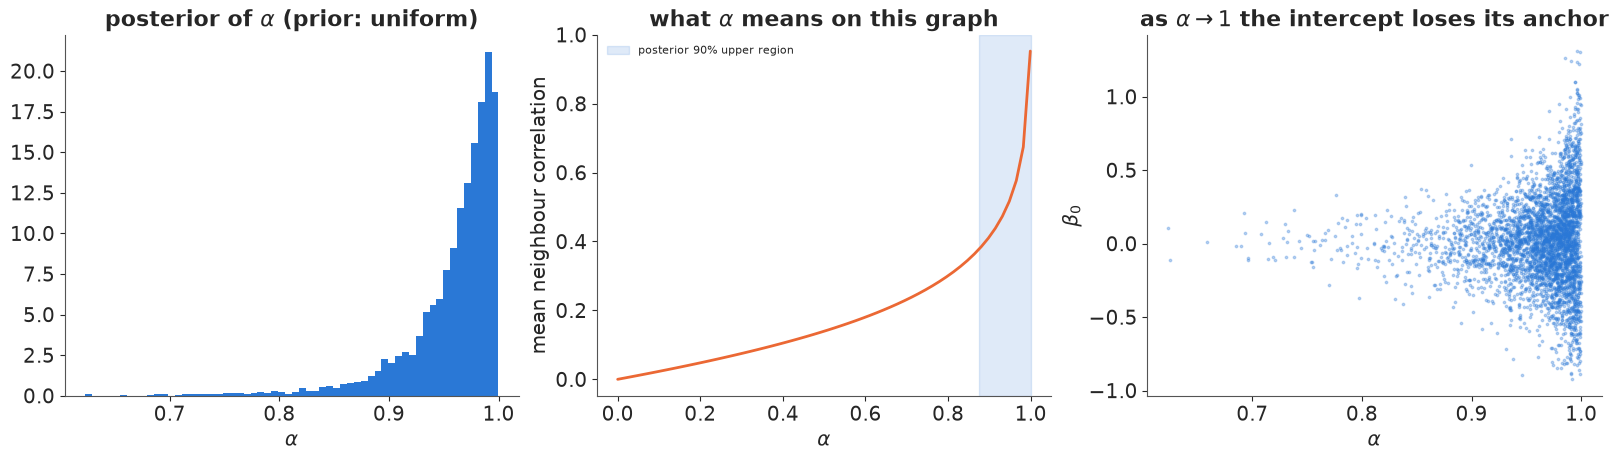

In [15]:
alpha_draws = fits["car"].posterior["alpha"].to_numpy().ravel()
print(f"alpha: median {np.median(alpha_draws):.3f}, 5% quantile {np.quantile(alpha_draws, 0.05):.3f}")
print(f"b0 ESS bulk: CAR {float(az.ess(fits['car'], var_names=['b0'])['b0']):.0f}, "
      f"BYM2 {float(az.ess(fits['bym2'], var_names=['b0'])['b0']):.0f}")

alphas = np.linspace(0.0, 0.999, 60)
neigh_corr = []
for a in alphas:
    cov = np.linalg.inv(np.diag(W.sum(1)) - a * W)
    c = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
    neigh_corr.append(c[iu][is_edge].mean())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(alpha_draws, bins=60, color=BLUE, density=True)
axes[0].set(xlabel=r"$\alpha$", title=r"posterior of $\alpha$ (prior: uniform)")
axes[1].plot(alphas, neigh_corr, color=ORANGE, lw=2)
axes[1].set(xlabel=r"$\alpha$", ylabel="mean neighbour correlation",
            title=r"what $\alpha$ means on this graph")
axes[1].axvspan(np.quantile(alpha_draws, 0.05), 1, color=BLUE, alpha=0.15, label="posterior 90% upper region")
axes[1].legend(fontsize=8)
axes[2].scatter(alpha_draws, fits["car"].posterior["b0"].to_numpy().ravel(), s=3, alpha=0.3, color=BLUE)
axes[2].set(xlabel=r"$\alpha$", ylabel=r"$\beta_0$", title=r"as $\alpha \to 1$ the intercept loses its anchor");

Two reasons, both structural rather than numerical:

* **$\alpha$ is not a correlation.** On this graph the average prior correlation between
  neighbours is still below 0.3 at $\alpha = 0.8$ and only climbs steeply in the last few
  hundredths before 1. A uniform prior on $\alpha$ therefore puts most of its mass on
  *weak* spatial dependence, and data with real spatial structure have to push $\alpha$
  into the corner (Wall 2004 documents this for US states).
* **At $\alpha \to 1$ the constant direction becomes (almost) free.** The proper CAR's
  precision approaches the singular Laplacian, so the mean level of $\phi$ and the
  intercept $\beta_0$ trade off, as the right panel shows. That is where the low ESS of
  $\beta_0$ comes from.

**Fix**: use the ICAR (the $\alpha = 1$ limit, with the constraint that removes the free
direction) and, when the data may be less smooth, mix it with iid noise - which is BYM2.
The proper CAR still has its place (it is a valid model on graphs where you *want* weak
dependence and a proper prior), but $\alpha$ should not be read as "how spatial".

### Failure 3: the unscaled BYM - two scales that do not mean the same thing

The original BYM puts separate priors on $\sigma_\phi$ (ICAR) and $\sigma_\theta$ (iid). It
samples fine here, but its parameters are hard to read and its priors are silently
unequal.

In [16]:
fit_bym = fit(build("bym"), loglik=False)
print(diagnostics(fit_bym, ["b0", "b1", "sigma_phi", "sigma_theta"]))
post_bym = az.extract(fit_bym, var_names=["sigma_phi", "sigma_theta"])
sp, st = post_bym["sigma_phi"].to_numpy(), post_bym["sigma_theta"].to_numpy()
print(f"corr(sigma_phi, sigma_theta) = {np.corrcoef(sp, st)[0, 1]:.2f}")
naive = sp**2 / (sp**2 + st**2)
marginal = s * sp**2 / (s * sp**2 + st**2)
rho_bym2 = fits["bym2"].posterior["rho"].to_numpy().ravel()
print(f"'spatial share' sigma_phi^2 / (sigma_phi^2 + sigma_theta^2): median {np.median(naive):.2f}")
print(f"same with the ICAR's actual marginal variance s * sigma_phi^2: median {np.median(marginal):.2f}")
print(f"BYM2 rho: median {np.median(rho_bym2):.2f}")
sp0, st0 = np.abs(rng.standard_normal((2, 100_000)))  # the BYM prior: two HalfNormal(1) scales
share0 = s * sp0**2 / (s * sp0**2 + st0**2)
print(f"prior on the spatial share implied by the BYM priors: median {np.median(share0):.2f}, "
      f"P(share > 0.5) = {np.mean(share0 > 0.5):.2f}   (BYM2: 0.50 and 0.50 by construction)")

              mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
b0           0.100  0.056     0.010     0.187  4623.618  3488.097  1.003   
b1           0.390  0.133     0.179     0.597  3217.581  3100.696  1.001   
sigma_phi    0.633  0.128     0.441     0.844   770.578   872.236  1.008   
sigma_theta  0.149  0.104     0.016     0.340   708.396   895.144  1.009   

             divergences  
b0                     0  
b1                     0  
sigma_phi              0  
sigma_theta            0  
corr(sigma_phi, sigma_theta) = -0.33
'spatial share' sigma_phi^2 / (sigma_phi^2 + sigma_theta^2): median 0.96
same with the ICAR's actual marginal variance s * sigma_phi^2: median 0.94
BYM2 rho: median 0.86
prior on the spatial share implied by the BYM priors: median 0.39, P(share > 0.5) = 0.43   (BYM2: 0.50 and 0.50 by construction)


$\sigma_\phi$ is a **conditional** standard deviation (of $\phi_i$ given its neighbours,
for one neighbour), while $\sigma_\theta$ is a **marginal** one. On this graph a unit ICAR
has typical marginal variance $s \approx 0.63$, so the same HalfNormal(1) prior on the two
scales quietly favours the iid part (the implied prior on the spatial share has its median
below 0.5) - and on a different map, with another $s$, the tilt would be different. The two
scales are also negatively correlated in the posterior: the data constrain their total
better than their split.

The posterior share differs between the two parameterisations - about 0.94 for BYM, 0.86
for BYM2's $\rho$ - and neither is "the" answer: the data say "mostly spatial", and the
rest is prior, which also enters through the priors on the total scale. With BYM that prior
is implicit and graph-dependent; with BYM2 you set it directly on the quantity you report,
and the same prior means the same thing on every map.

## 6 · BYM2: how spatial is the risk?

rho: median 0.86, 90% interval [0.52, 0.99]; P(rho > 0.5) = 0.96


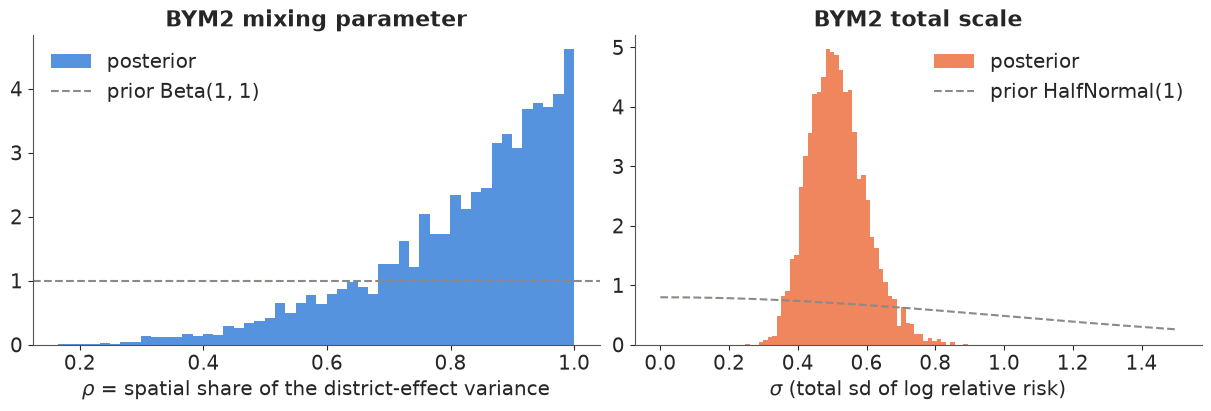

In [17]:
post2 = az.extract(fits["bym2"], var_names=["sigma", "rho"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(post2["rho"].to_numpy(), bins=50, density=True, color=BLUE, alpha=0.8, label="posterior")
axes[0].axhline(1, color=GREY, ls="--", label="prior Beta(1, 1)")
axes[0].set(xlabel=r"$\rho$ = spatial share of the district-effect variance", title=r"BYM2 mixing parameter")
axes[0].legend()
axes[1].hist(post2["sigma"].to_numpy(), bins=50, density=True, color=ORANGE, alpha=0.8, label="posterior")
sig_grid = np.linspace(0, 1.5, 200)
axes[1].plot(sig_grid, stats.halfnorm(scale=1).pdf(sig_grid), color=GREY, ls="--", label="prior HalfNormal(1)")
axes[1].set(xlabel=r"$\sigma$ (total sd of log relative risk)", title="BYM2 total scale")
axes[1].legend()
print(f"rho: median {np.median(post2['rho']):.2f}, 90% interval "
      f"[{np.quantile(post2['rho'], 0.05):.2f}, {np.quantile(post2['rho'], 0.95):.2f}]; P(rho > 0.5) = "
      f"{np.mean(post2['rho'].to_numpy() > 0.5):.2f}")

Most of the district-to-district variation beyond AFF is spatially structured: $\rho$'s
posterior is concentrated well above 0.5, with a long tail down that reflects how little
56 districts can say about a variance split. In epidemiological terms: after adjusting for
outdoor work, a district's lip-cancer risk is better predicted by its neighbours' risk than
by an independent district-level quirk - pointing to further unmeasured, geographically
smooth risk factors (sun exposure that the share of outdoor workers does not capture, for
instance).

## 7 · Maps: what to report

The raw SMR map is the wrong thing to publish: its most extreme colours belong to the
smallest districts. The BYM2 posterior gives two better maps: the **smoothed relative risk**
(posterior median of $r_i$), and the **exceedance probability** $P(r_i > 1 \mid y)$ - the
answer to "is this district's risk really above the national level?"

19 districts with P(RR > 1) > 0.95, 14 with P(RR > 1) < 0.05


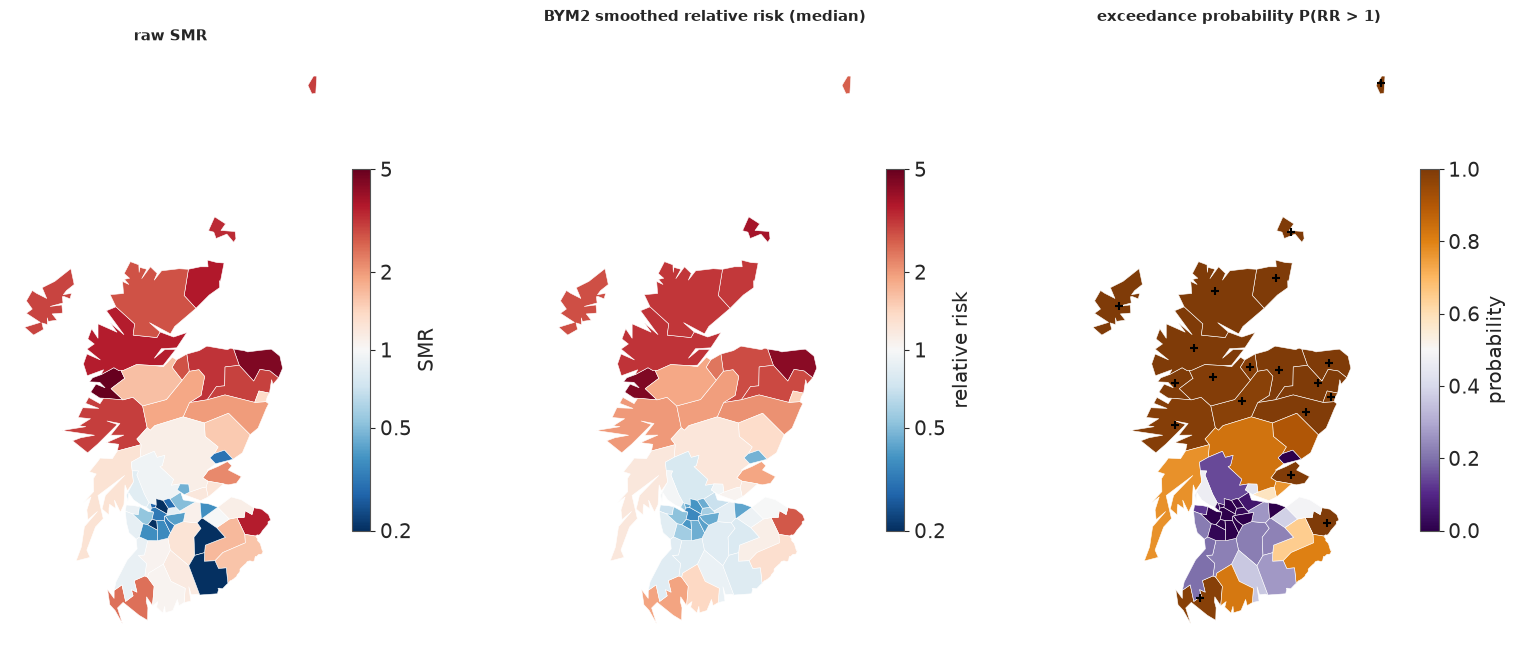

In [18]:
rr_draws = np.exp(fits["bym2"].posterior["log_rr"].to_numpy().reshape(-1, N))
rr_med = np.median(rr_draws, 0)
p_exceed = (rr_draws > 1).mean(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))
pc = draw_map(axes[0], np.log(np.clip(lip.SMR, 0.2, None)), cmap="RdBu_r", norm=RR_NORM, title="raw SMR", cbar_label="SMR")
rr_colorbar_ticks(pc)
pc = draw_map(axes[1], np.log(rr_med), cmap="RdBu_r", norm=RR_NORM, title="BYM2 smoothed relative risk (median)",
              cbar_label="relative risk")
rr_colorbar_ticks(pc)
draw_map(axes[2], p_exceed, cmap="PuOr_r", norm=TwoSlopeNorm(vcenter=0.5, vmin=0, vmax=1),
         title="exceedance probability P(RR > 1)", cbar_label="probability")
hot = p_exceed > 0.95
axes[2].scatter(*centroids[hot].T, marker="+", color="k", s=40)
print(f"{hot.sum()} districts with P(RR > 1) > 0.95, {(p_exceed < 0.05).sum()} with P(RR > 1) < 0.05")

The smoothed map keeps the north-west / central-belt contrast but tones down the extremes,
and the zero-count districts in the south-east are no longer painted as the healthiest in
Scotland. The exceedance map (crosses: $P > 0.95$) is what a public-health reader should
see: it separates "high and certain" from "high but based on nine cases".

### Shrinkage: who moved, and why

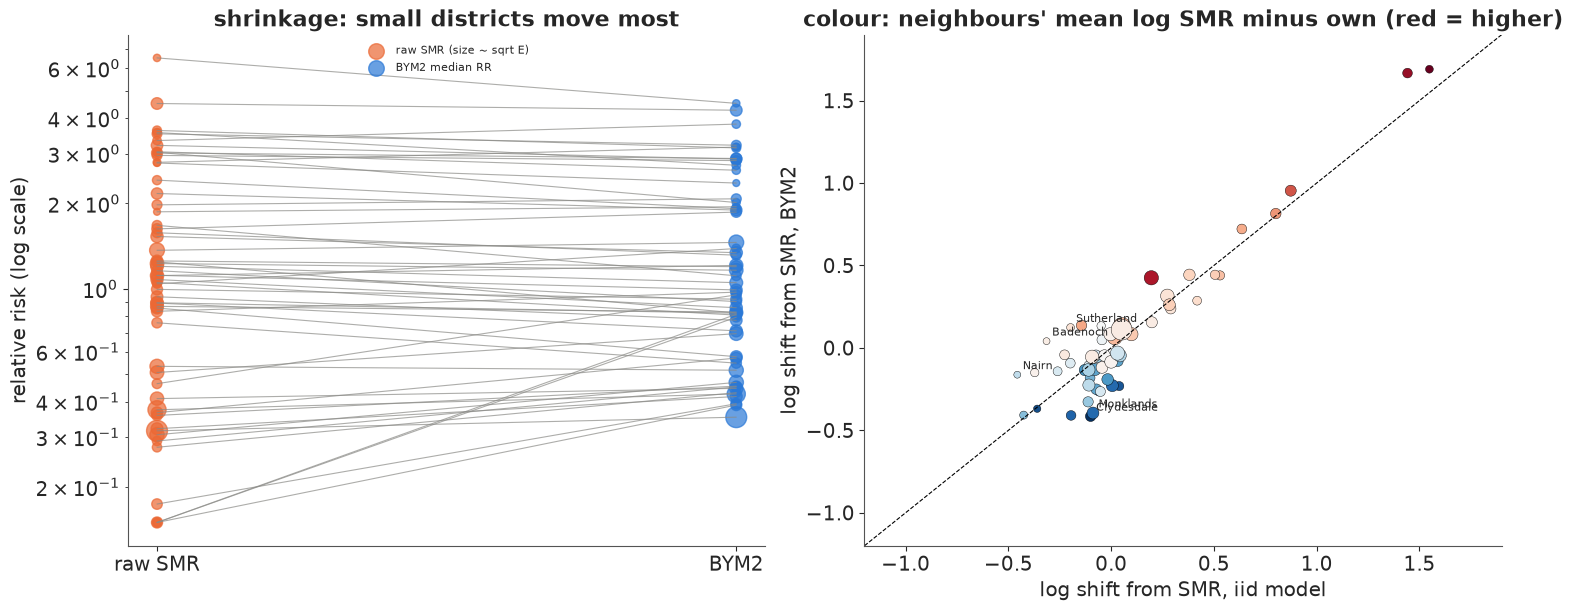

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
rr_iid = np.median(np.exp(fits["iid"].posterior["log_rr"].to_numpy().reshape(-1, N)), 0)
smr_plot = np.clip(lip.SMR.to_numpy(), 0.15, None)
ax = axes[0]
for i in range(N):
    ax.plot([0, 1], [smr_plot[i], rr_med[i]], color=GREY, lw=0.8, alpha=0.7)
ax.scatter(np.zeros(N), smr_plot, s=8 * np.sqrt(E) * 3, color=ORANGE, alpha=0.7, label="raw SMR (size ~ sqrt E)")
ax.scatter(np.ones(N), rr_med, s=8 * np.sqrt(E) * 3, color=BLUE, alpha=0.7, label="BYM2 median RR")
ax.set(yscale="log", xticks=[0, 1], xticklabels=["raw SMR", "BYM2"], ylabel="relative risk (log scale)",
       title="shrinkage: small districts move most")
ax.legend(loc="upper center", fontsize=8)
ax = axes[1]
nb_mean = np.array([np.mean(np.log(smr_plot[W[i] == 1])) for i in range(N)])
ax.scatter(np.log(rr_iid) - np.log(smr_plot), np.log(rr_med) - np.log(smr_plot), c=nb_mean - np.log(smr_plot),
           cmap="RdBu_r", s=8 * np.sqrt(E) * 3, norm=TwoSlopeNorm(0), edgecolor="k", lw=0.3)
lim = [-1.2, 1.9]
ax.plot(lim, lim, color="k", lw=0.8, ls="--")
ax.set(xlim=lim, ylim=lim, xlabel="log shift from SMR, iid model", ylabel="log shift from SMR, BYM2",
       title="colour: neighbours' mean log SMR minus own (red = higher)")
for i in np.argsort(-np.abs(np.log(rr_med) - np.log(rr_iid)))[:5]:
    ax.annotate(names[i], (np.log(rr_iid[i]) - np.log(smr_plot[i]), np.log(rr_med[i]) - np.log(smr_plot[i])),
                fontsize=8, xytext=(4, 4), textcoords="offset points");

(Zero counts are drawn at SMR 0.15: they are the two points at the top right.) Left: every
district is pulled towards a consensus, and the small ones (small dots) move
the most - the usual hierarchical-model shrinkage (E02). Right: *where* they are pulled
differs between the models. The iid model pulls every district towards the same national
regression line; BYM2 pulls it towards its **neighbours**. Points off the diagonal are
districts where the two disagree, and the colour shows why: districts whose neighbours have
higher SMRs (red) are pulled up more by BYM2 than by the iid model, and vice versa.

## 8 · Model comparison: LOO, and why to distrust it here

In [20]:
comparison = az.compare(loos, round_to=1)
print(comparison[["elpd", "elpd_diff", "dse", "p", "weight"]])
pd.DataFrame({k: [(v.pareto_k.values > 0.7).sum(), v.pareto_k.values.max().round(2)] for k, v in loos.items()},
             index=["Pareto k > 0.7", "max k"]).T

          elpd  elpd_diff   dse     p  weight
icar    -151.9        0.0   0.0  24.5     1.0
bym2    -152.7       -0.8   0.7  25.8     0.0
car     -152.8       -0.9   0.8  25.7     0.0
iid     -163.6      -11.7   3.1  37.1     0.0
poisson -230.7      -78.8  20.1  11.4     0.0


,Pareto k > 0.7,max k
poisson,0.0,0.69
iid,28.0,1.24
icar,17.0,0.98
car,17.0,1.02
bym2,24.0,1.03


LOO ranks the three graph models within one elpd of each other, all 11-12 above iid
(3-4 standard errors), which is itself far above the Poisson-only model. But look at the
Pareto $k$: between 17 and 28 of the 56 districts have $k > 0.7$ in every random-effects
model. That is structural, not a bug: each district's
count is the main source of information about its own effect $u_i$, so deleting it
changes the posterior too much for importance sampling to recover. The ranking is
plausible, but these elpd values should not be quoted as precise.

The honest check is to actually refit without the held-out districts. Leaving a district
out is also exactly the prediction problem an areal model is for: **what is the risk in a
district we have no data for?** The iid model can only answer with the regression line;
the graph models answer with the neighbours. We run 8-fold cross-validation (7 districts
per fold, the same folds for every model) and score the held-out counts with the exact
log predictive density. That is 32 fits of a few seconds each.

In [21]:
folds = np.array_split(rng.permutation(N), 8)
cv_models = ["iid", "icar", "car", "bym2"]
elpd_cv = {k: np.zeros(N) for k in cv_models}
for kind in cv_models:
    for test in folds:
        train = np.setdiff1d(np.arange(N), test)
        idata_k = fit(build(kind, obs_idx=train), loglik=False)
        mu = E[test] * np.exp(idata_k.posterior["log_rr"].isel(district=test).to_numpy().reshape(-1, len(test)))
        elpd_cv[kind][test] = logsumexp(stats.poisson.logpmf(y[test], mu), axis=0) - np.log(mu.shape[0])
        del idata_k
cv = pd.DataFrame({"elpd (8-fold)": {k: v.sum() for k, v in elpd_cv.items()},
                   "se": {k: np.sqrt(N) * v.std() for k, v in elpd_cv.items()}})
cv["diff vs BYM2"] = cv["elpd (8-fold)"] - cv.loc["bym2", "elpd (8-fold)"]
cv["se of diff"] = {k: np.sqrt(N) * (elpd_cv[k] - elpd_cv["bym2"]).std() for k in cv_models}
cv.round(1)

,elpd (8-fold),se,diff vs BYM2,se of diff
iid,-175.1,6.4,-17.8,3.5
icar,-156.4,5.8,1.0,0.6
car,-157.1,5.7,0.3,0.7
bym2,-157.4,5.7,0.0,0.0


Cross-validation that genuinely withholds districts gives lower elpd than PSIS-LOO for
every model (8-fold holds out 7 districts at a time, and PSIS was optimistic where $k$ was
high), but it confirms the ordering: **predicting a district from its neighbours beats
predicting it from the covariate alone** by about 18 elpd, five standard errors, while the
three graph models are close: the pure ICAR scores about 1 higher than BYM2 (the paired
difference has a standard error of about 0.6), consistent with $\rho$ near 1 - when almost
all the variation is spatial, the iid part of BYM2 mostly adds noise to the prediction of a
held-out district. That is about 1 nat summed over 56 districts, a small difference; with this
much data the choice between ICAR, proper CAR and BYM2 is better made on interpretability
and behaviour (BYM2: an interpretable $\rho$, priors that transfer between maps, no
boundary problem, and safety when the data are *not* so spatial).

## 9 · The covariate: spatial confounding

The AFF effect fell from about 0.67 to about 0.4 when the spatial term went in. Which is
the effect of outdoor work?

           5%  median   95%  RR per +10 points (median)
poisson  0.64    0.74  0.83                        2.09
iid      0.43    0.67  0.91                        1.96
icar     0.17    0.38  0.57                        1.46
car      0.18    0.40  0.60                        1.49
bym2     0.19    0.41  0.62                        1.50
correlation between AFF and the BYM2 district effect: 0.35


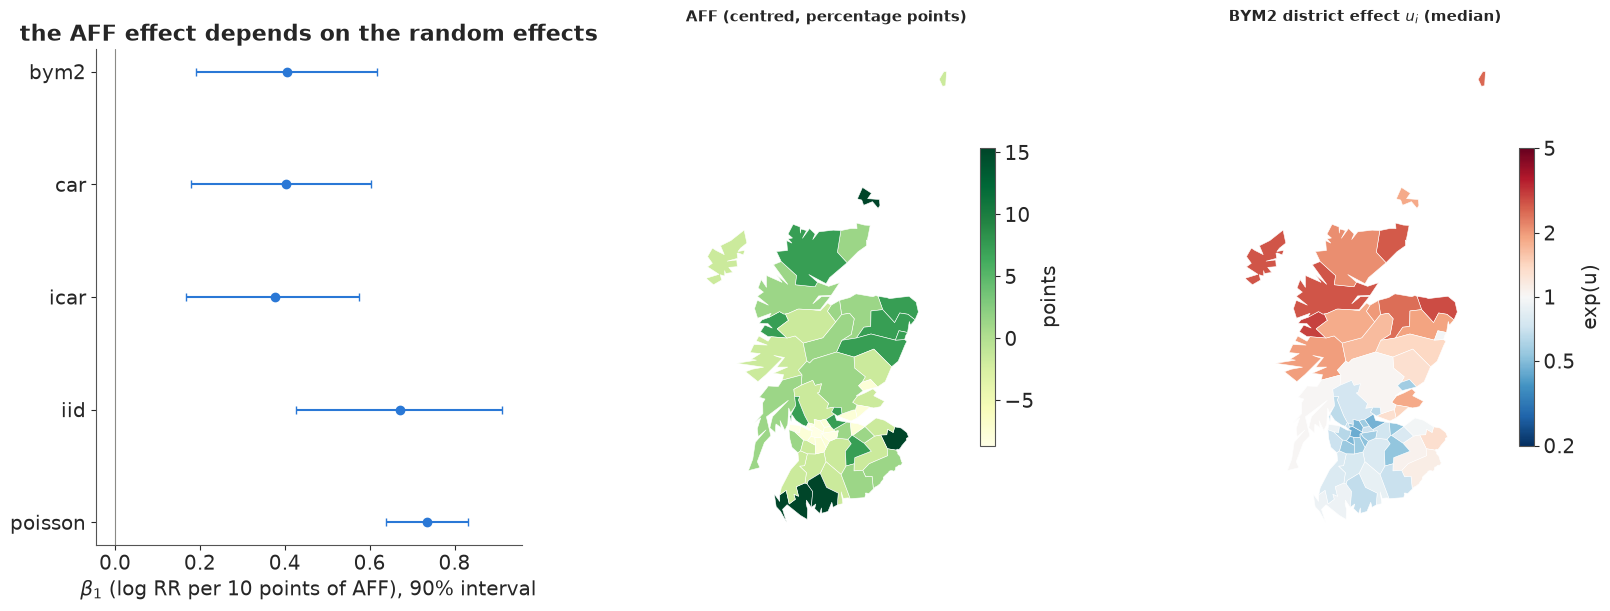

In [22]:
b1_tab = pd.DataFrame({k: np.quantile(fits[k].posterior["b1"].to_numpy().ravel(), [0.05, 0.5, 0.95]) for k in kinds},
                      index=["5%", "median", "95%"]).T
b1_tab["RR per +10 points (median)"] = np.exp(b1_tab["median"])
print(b1_tab.round(2))

pb = az.extract(fits["bym2"], var_names=["log_rr", "b0", "b1"])
u_draws = pb["log_rr"].to_numpy() - pb["b0"].to_numpy() - np.outer(x, pb["b1"].to_numpy())  # (district, sample)
u_med = np.median(u_draws, 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig_x = np.arange(len(kinds))
axes[0].errorbar(b1_tab["median"], fig_x, xerr=[b1_tab["median"] - b1_tab["5%"], b1_tab["95%"] - b1_tab["median"]],
                 fmt="o", color=BLUE, capsize=3)
axes[0].set(yticks=fig_x, yticklabels=kinds, xlabel=r"$\beta_1$ (log RR per 10 points of AFF), 90% interval",
            title="the AFF effect depends on the random effects")
axes[0].axvline(0, color=GREY, lw=0.8)
draw_map(axes[1], x * 10, cmap="YlGn", title="AFF (centred, percentage points)", cbar_label="points")
pc = draw_map(axes[2], u_med, cmap="RdBu_r", norm=RR_NORM, title="BYM2 district effect $u_i$ (median)", cbar_label="exp(u)")
rr_colorbar_ticks(pc)
print(f"correlation between AFF and the BYM2 district effect: {np.corrcoef(x, u_med)[0, 1]:.2f}")

AFF is itself spatially patterned (Moran's I 0.29 in section 2): high in the north and the
rural south-west, low in the central belt, much like the risk. Part of it therefore lies in
the space that the spatial effect can also represent, and the estimated district effect
is still correlated with AFF (0.35). The model cannot distinguish "outdoor work raises
risk" from "the north has higher risk for reasons we have not measured, and happens to farm
and fish", so it splits the credit: the AFF coefficient drops by about 40% (from a relative
risk of about 1.96 to about 1.5 per 10 points). This is **spatial confounding** (Clayton, Bernardinelli & Montomoli 1993;
Hodges & Reich 2010).

Neither number is "the" effect:

* The **iid** estimate assumes nothing else varies smoothly across Scotland. If an unmeasured
  smooth risk factor exists, and is correlated with AFF, it is attributed to AFF: biased
  upwards.
* The **spatial** estimate adjusts for *any* smooth confounder, but also for the part of the
  true AFF effect that is smooth. If AFF were the whole story, the spatial term would
  still absorb some of it: biased towards zero, and less certain.

"Restricted spatial regression" (forcing $u$ to be orthogonal to $x$) gives back the iid
point estimate with spatial-model uncertainty; it is now generally discouraged because it
simply assumes the confounding away (Khan & Calder 2022). The defensible position is the
honest one: AFF is associated with risk in every model (the 90% intervals exclude 0), the
size of the association depends on what one assumes about unmeasured spatial factors, and
only better data (a measured sunlight exposure, individual-level occupation) could settle it.

## 10 · Summary

| Step | What we did | What to remember |
|---|---|---|
| Graph | queen contiguity from shared polygon vertices; compared with a published list | build the graph yourself and look at it on a map; published lists contain decisions and errors |
| Anatomy | degrees, connected components, islands | each component adds a free constant; islands need an explicit decision |
| ICAR | `pm.ICAR`, soft sum-to-zero, non-centred | prior variances come from the graph; no forward sampling |
| Proper CAR | `pm.CAR` with $\alpha \sim U(0, 1)$ | $\alpha$ piles up near 1 and is not a correlation; $\beta_0$ mixes poorly |
| BYM2 | ICAR / $\sqrt{s}$ + iid, total $\sigma$, mixing $\rho$ | $s$ from the generalised inverse of the Laplacian; $\rho$ = spatial share |
| Checks | Moran's I of residual effects; 90% interval coverage | independent effects absorb overdispersion but not structure |
| Reporting | smoothed RR and $P(RR > 1)$ maps, shrinkage plot | never publish raw SMRs of small areas |
| Comparison | PSIS-LOO (many high $k$) and 8-fold CV | refit when $k$ is high; the graph models tie |
| Covariate | $\beta_1$ across models | spatial confounding: the effect depends on assumptions about unmeasured smooth factors |

**Adjacency vs distance (E07).** E07 put a Gaussian process on coordinates: correlation
decays smoothly with kilometres, a lengthscale is learned, and prediction works anywhere on
the map. Here correlation follows the graph: it ignores kilometres, adapts to areas of very
different sizes, costs a sparse matrix instead of a dense kernel, and predicts only for
the areas in the graph. Use a GP when the process is continuous in space and the data are
points; use a graph prior when the areas themselves are the units.

## Try it yourself

1. **Per-component ICAR.** Write the ICAR density for the raw four-component graph with a
   sum-to-zero constraint per component (e.g. `pm.Potential` on the edge differences plus one
   `pm.Normal` constraint per component) and give the singleton islands iid effects only.
   How do the island relative risks compare with the "linked" and "isolated" versions?
2. **Whose graph?** Refit BYM2 on the published WinBUGS list (`W_bugs`) and on the rook
   graph. How much do $\rho$, $\beta_1$ and the exceedance map change? Then correct the
   Tweeddale/Annandale swap in `W_bugs` and refit.
3. **A penalised-complexity prior for $\rho$.** Riebler et al. (2016) recommend a PC prior
   that shrinks towards $\rho = 0$ (no spatial structure). Replace the Beta(1, 1) with a
   prior putting $P(\rho < 0.5) = 2/3$ and see whether the data still pull $\rho$ up. Also try
   a GP on the district centroids (`pm.gp.HSGP` in 2-D, as in E07) and compare its 8-fold
   elpd with BYM2's.